In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/processed/final_financial_data.csv")

df["Transaction_Date"] = pd.to_datetime(
    df["Transaction_Date"],
    format="mixed",
    dayfirst=True
)

gb_model = joblib.load("../models/gradient_boosting_expense_model.pkl")

In [3]:
df["Year_Month"] = df["Transaction_Date"].dt.to_period("M")

monthly_expenses = (
    df[df["Transaction_Type"] == "Expense"]
    .groupby("Year_Month")["Amount"]
    .sum()
    .sort_index()
)

monthly_expenses.tail()

Year_Month
2025-08    29561517.05
2025-09    42182363.12
2025-10    29428396.97
2025-11    38886833.03
2025-12    49635181.02
Freq: M, Name: Amount, dtype: float64

In [4]:
# Copy monthly expense data
forecast_series = monthly_expenses.copy()

# Display the latest 12 months
forecast_series.tail(12)

Year_Month
2025-01    24797184.21
2025-02    31842838.34
2025-03    35885210.66
2025-04    30097500.66
2025-05    33923902.40
2025-06    51270896.97
2025-07    31633945.62
2025-08    29561517.05
2025-09    42182363.12
2025-10    29428396.97
2025-11    38886833.03
2025-12    49635181.02
Freq: M, Name: Amount, dtype: float64

In [5]:
# Create a copy so the original historical data is not changed
forecast_series_2026 = forecast_series.copy()

# Store predictions
predictions_2026 = {}

# Generate forecasts month by month
for month in range(1, 13):

    forecast_date = pd.Period(f"2026-{month:02d}", freq="M")

    lag_1 = forecast_series_2026.iloc[-1]
    lag_2 = forecast_series_2026.iloc[-2]
    lag_3 = forecast_series_2026.iloc[-3]
    lag_12 = forecast_series_2026.iloc[-12]

    rolling_mean_3 = forecast_series_2026.iloc[-3:].mean()

    month_number = forecast_date.month
    quarter = forecast_date.quarter

    X_future = pd.DataFrame({
        "Lag_1": [lag_1],
        "Lag_2": [lag_2],
        "Lag_3": [lag_3],
        "Lag_12": [lag_12],
        "Rolling_Mean_3": [rolling_mean_3],
        "Month": [month_number],
        "Quarter": [quarter]
    })

    prediction = gb_model.predict(X_future)[0]

    predictions_2026[forecast_date] = prediction

    # Add prediction to the series for the next month's forecast
    forecast_series_2026.loc[forecast_date] = prediction

predictions_2026

{Period('2026-01', 'M'): 33509742.996780895,
 Period('2026-02', 'M'): 36559223.975602925,
 Period('2026-03', 'M'): 41634461.556731954,
 Period('2026-04', 'M'): 41013772.71384561,
 Period('2026-05', 'M'): 38531266.143742464,
 Period('2026-06', 'M'): 43197474.21950641,
 Period('2026-07', 'M'): 39426091.246101625,
 Period('2026-08', 'M'): 39426091.246101625,
 Period('2026-09', 'M'): 43185923.86037638,
 Period('2026-10', 'M'): 39389597.0322425,
 Period('2026-11', 'M'): 46055743.17590959,
 Period('2026-12', 'M'): 48943798.486628264}

In [6]:
forecast_2026_df = pd.DataFrame(
    list(predictions_2026.items()),
    columns=["Year_Month", "Forecasted_Expense"]
)

forecast_2026_df

,Year_Month,Forecasted_Expense
0,2026-01,3.350974e+07
1,2026-02,3.655922e+07
2,2026-03,4.163446e+07
3,2026-04,4.101377e+07
4,2026-05,3.853127e+07
5,2026-06,4.319747e+07
6,2026-07,3.942609e+07
7,2026-08,3.942609e+07
8,2026-09,4.318592e+07
9,2026-10,3.938960e+07


In [7]:
forecast_2026_df["Forecasted_Expense"] = (
    forecast_2026_df["Forecasted_Expense"].round(2)
)

forecast_2026_df

,Year_Month,Forecasted_Expense
0,2026-01,33509743.00
1,2026-02,36559223.98
2,2026-03,41634461.56
3,2026-04,41013772.71
4,2026-05,38531266.14
5,2026-06,43197474.22
6,2026-07,39426091.25
7,2026-08,39426091.25
8,2026-09,43185923.86
9,2026-10,39389597.03


In [8]:
total_2026_forecast = forecast_2026_df["Forecasted_Expense"].sum()
average_2026_forecast = forecast_2026_df["Forecasted_Expense"].mean()

print("Total Forecasted Expense for 2026:", round(total_2026_forecast, 2))
print("Average Monthly Forecasted Expense:", round(average_2026_forecast, 2))

Total Forecasted Expense for 2026: 490873186.67
Average Monthly Forecasted Expense: 40906098.89


In [9]:
actual_2025_expense = monthly_expenses[
    monthly_expenses.index.year == 2025
].sum()

growth_percentage = (
    (total_2026_forecast - actual_2025_expense)
    / actual_2025_expense
) * 100

print("Actual Expense in 2025:", round(actual_2025_expense, 2))
print("Forecasted Expense in 2026:", round(total_2026_forecast, 2))
print("Expected Expense Growth:", round(growth_percentage, 2), "%")

Actual Expense in 2025: 429145770.05
Forecasted Expense in 2026: 490873186.67
Expected Expense Growth: 14.38 %


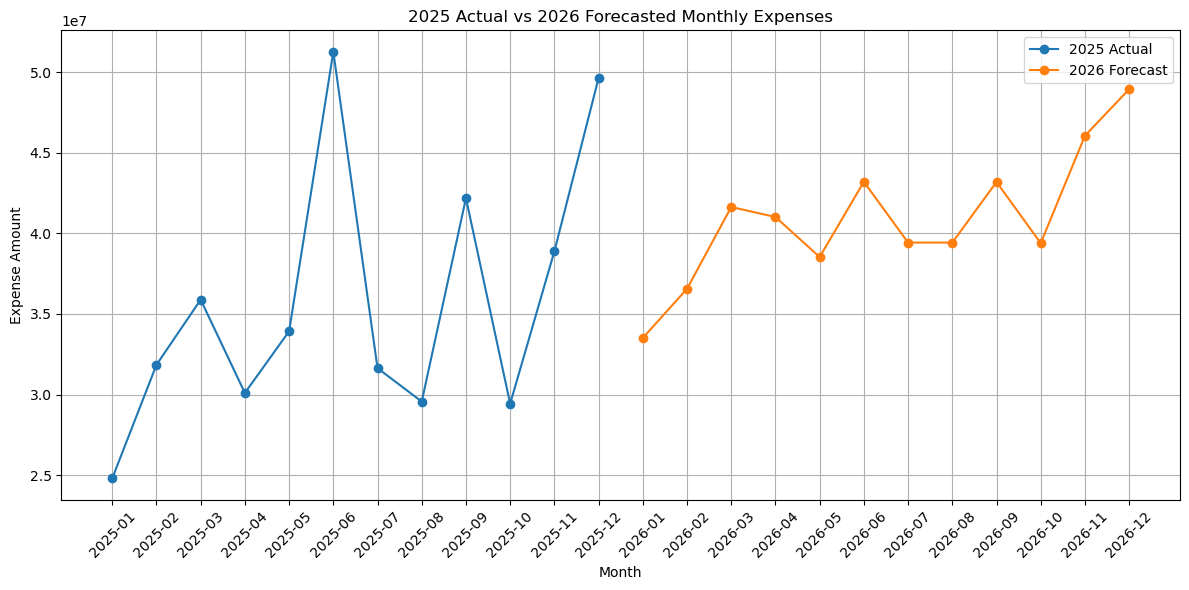

In [10]:
# Prepare 2025 actual expenses
actual_2025 = monthly_expenses[
    monthly_expenses.index.year == 2025
]

# Create the chart
plt.figure(figsize=(12, 6))

plt.plot(
    actual_2025.index.astype(str),
    actual_2025.values,
    marker="o",
    label="2025 Actual"
)

plt.plot(
    forecast_2026_df["Year_Month"].astype(str),
    forecast_2026_df["Forecasted_Expense"],
    marker="o",
    label="2026 Forecast"
)

plt.title("2025 Actual vs 2026 Forecasted Monthly Expenses")
plt.xlabel("Month")
plt.ylabel("Expense Amount")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [11]:
forecast_2026_df.to_csv(
    "../data/processed/expense_forecast_2026.csv",
    index=False
)

print("2026 expense forecast saved successfully.")

2026 expense forecast saved successfully.
